# Mine hard pose examples from the candidate crop pool

The candidate pool (`dataset/pose/pose-crops-candidates/`, ~700 cam1 crops from the recommended videos + a random spread) is more than we want to label. This notebook curates it down to the **~300 most useful** crops to label, using where the current best model (**v4**) struggles:

- **Method 1 — confidence:** mean visible-keypoint confidence per crop. Low confidence ↔ occlusion, blur, odd angle, overlap.
- **Method 2 — geometry outliers:** limb-segment lengths (head–neck, neck–back, back–tail) normalized by box diagonal, compared to the mean/std of the **labeled pose dataset (ground truth)**. Large z-scores ↔ implausible skeletons (failures).

Selected = bottom-percentile confidence ∪ geometry outliers, topped up to the target with the lowest-confidence remainder. Selected crops are copied to `dataset/pose/pose-crops-to-label/` for Roboflow.

Run top to bottom; tune `BOTTOM_PCT`, `GEOM_Z`, and `TARGET` in the config cell, re-run, and review the montage before labeling.

In [1]:
import os, json, warnings, shutil
warnings.filterwarnings("ignore")
from pathlib import Path
import cv2
import numpy as np
from ultralytics import YOLO

# Resolve repo root.
root = Path.cwd()
for _ in range(6):
    if (root / "pen_config.json").exists():
        break
    root = root.parent
os.chdir(root)

POSE_MODEL = "runs/pose/runs/pose/hen_pose_yolo12s_aug_v4/weights/best.pt"
POOL       = Path("dataset/pose/pose-crops-candidates")        # candidate pool to curate
GT_DATASET = Path("dataset/pose/pose-dataset-merged-split")    # GT for geometry reference (base order)
OUT        = Path("dataset/pose/pose-crops-to-label")          # selected hard examples

# Selection knobs (tune and re-run).
BOTTOM_PCT = 10      # bottom % by confidence flagged as hard (Method 1)
GEOM_Z     = 3.0     # limb-length z-score beyond which a pose is an outlier (Method 2)
TARGET     = 300     # total crops to select for labeling

N_KPTS = 10
CONF = 0.25
# base keypoint order: 0 tail_base 1 tail_tip 2 left_hock 3 right_hock 4 left_foot
#                      5 right_foot 6 neck_back 7 middle_back 8 comb 9 beak
SEG_PAIRS = {"head_neck": (8, 6), "neck_back": (6, 7), "back_tail": (7, 0)}

pose = YOLO(POSE_MODEL)
pool_imgs = sorted(POOL.glob("*.jpg"))
print("pool crops:", len(pool_imgs))

pool crops: 717


In [2]:
# Helpers + geometry reference computed from the labeled pose dataset (GT).
def diag(box):
    return float(np.hypot(box[2] - box[0], box[3] - box[1]))

def seg_ratios_from_kpts(kpts, box):
    """kpts (10,3) pixels -> {segment: length / box-diagonal} for visible pairs."""
    d = diag(box)
    out = {}
    if d <= 0:
        return out
    for name, (a, b) in SEG_PAIRS.items():
        if kpts[a, 2] > 0 and kpts[b, 2] > 0:
            out[name] = float(np.hypot(kpts[a, 0] - kpts[b, 0], kpts[a, 1] - kpts[b, 1])) / d
    return out

# Reference distribution of each segment length from GT. Ratios are
# length/box-diagonal in normalized coords -> dimensionless and scale-invariant,
# so they are directly comparable to the pixel-space ratios of predictions.
ref = {k: [] for k in SEG_PAIRS}
for s in ("train", "val", "test"):
    for f in (GT_DATASET / "labels" / s).glob("*.txt"):
        for ln in f.read_text().splitlines():
            p = ln.split()
            if len(p) < 5 + N_KPTS * 3:
                continue
            bd = float(np.hypot(float(p[3]), float(p[4])))
            if bd <= 0:
                continue
            kp = np.array([float(v) for v in p[5:5 + N_KPTS * 3]], np.float32).reshape(N_KPTS, 3)
            for name, (a, b) in SEG_PAIRS.items():
                if kp[a, 2] > 0 and kp[b, 2] > 0:
                    ref[name].append(float(np.hypot(kp[a, 0] - kp[b, 0], kp[a, 1] - kp[b, 1])) / bd)

ref_stats = {k: (float(np.mean(v)), float(np.std(v) + 1e-6)) for k, v in ref.items() if v}
print("geometry reference (mean, std) from GT:")
for k, (m, s) in ref_stats.items():
    print(f"  {k}: mean={m:.3f} std={s:.3f}  (n={len(ref[k])})")

geometry reference (mean, std) from GT:
  head_neck: mean=0.139 std=0.054  (n=386)
  neck_back: mean=0.194 std=0.057  (n=378)
  back_tail: mean=0.204 std=0.065  (n=396)


In [3]:
# Score every pool crop with v4: mean keypoint confidence (Method 1) and
# the max limb-length z-score vs the GT reference (Method 2).
import pandas as pd
rows = []
for ip in pool_imgs:
    img = cv2.imread(str(ip))
    if img is None:
        continue
    r = pose.predict(img, conf=CONF, verbose=False)[0]
    if r.keypoints is None or r.boxes is None or len(r.boxes) == 0:
        rows.append({"file": ip.name, "mean_conf": 0.0, "max_z": 99.0, "n_vis": 0})
        continue
    i = int(r.boxes.conf.cpu().numpy().argmax())          # most confident hen in the crop
    kp = r.keypoints.data.cpu().numpy()[i]                 # (10, 3) pixels
    box = r.boxes.xyxy.cpu().numpy()[i]
    vis = kp[:, 2] > CONF
    mean_conf = float(kp[vis, 2].mean()) if vis.any() else 0.0
    ratios = seg_ratios_from_kpts(kp, box)
    zs = [abs(ratios[k] - ref_stats[k][0]) / ref_stats[k][1] for k in ratios if k in ref_stats]
    rows.append({"file": ip.name, "mean_conf": round(mean_conf, 4),
                 "max_z": round(float(max(zs)) if zs else 0.0, 3), "n_vis": int(vis.sum())})

df = pd.DataFrame(rows)
print(df[["mean_conf", "max_z", "n_vis"]].describe().round(3))
df.head()

       mean_conf    max_z    n_vis
count    717.000  717.000  717.000
mean       0.726    1.912    6.039
std        0.130    5.186    2.311
min        0.000    0.179    0.000
25%        0.649    1.109    5.000
50%        0.734    1.523    5.000
75%        0.828    2.083    8.000
max        0.958   99.000   10.000


,file,mean_conf,max_z,n_vis
0,cam1_20260605_141442_f17_h0.jpg,0.8621,1.647,10
1,cam1_20260605_141442_f17_h1.jpg,0.9000,2.038,10
2,cam1_20260605_141448_f1575_h0.jpg,0.7123,2.463,5
3,cam1_20260605_141448_f1575_h1.jpg,0.7499,1.846,10
4,cam1_20260605_141448_f1575_h2.jpg,0.7323,0.857,6


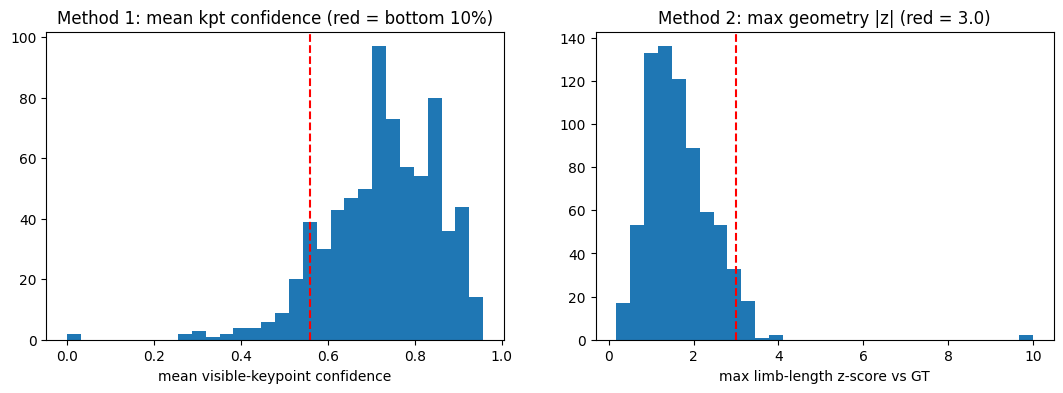

In [4]:
# Distributions: confidence (Method 1) and geometry z-score (Method 2).
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].hist(df["mean_conf"], bins=30)
ax[0].axvline(np.percentile(df["mean_conf"], BOTTOM_PCT), color="r", ls="--")
ax[0].set_title(f"Method 1: mean kpt confidence (red = bottom {BOTTOM_PCT}%)")
ax[0].set_xlabel("mean visible-keypoint confidence")
ax[1].hist(df["max_z"].clip(0, 10), bins=30)
ax[1].axvline(GEOM_Z, color="r", ls="--")
ax[1].set_title(f"Method 2: max geometry |z| (red = {GEOM_Z})")
ax[1].set_xlabel("max limb-length z-score vs GT")
plt.show()

In [5]:
# Select hard examples: bottom-percentile confidence UNION geometry outliers,
# topped up / trimmed to TARGET, and copy them out for labeling.
conf_thresh = np.percentile(df["mean_conf"], BOTTOM_PCT)
low_conf = set(df[df["mean_conf"] <= conf_thresh]["file"])
geom_out = set(df[df["max_z"] >= GEOM_Z]["file"])
selected = low_conf | geom_out
print(f"low-confidence: {len(low_conf)}   geometry-outlier: {len(geom_out)}   union: {len(selected)}")

if len(selected) < TARGET:                      # top up with the next-lowest confidence
    for f in df[~df["file"].isin(selected)].sort_values("mean_conf")["file"]:
        if len(selected) >= TARGET:
            break
        selected.add(f)
elif len(selected) > TARGET:                    # keep the hardest (lowest conf)
    selected = set(df[df["file"].isin(selected)].sort_values("mean_conf").head(TARGET)["file"])
print("final selected:", len(selected))

if OUT.exists():
    shutil.rmtree(OUT)
OUT.mkdir(parents=True, exist_ok=True)
for f in selected:
    shutil.copy2(POOL / f, OUT / f)
df["selected"] = df["file"].isin(selected)
df.to_csv(OUT / "mining_scores.csv", index=False)
print(f"copied {len(selected)} crops -> {OUT}")

low-confidence: 72   geometry-outlier: 39   union: 106
final selected: 300
copied 300 crops -> dataset\pose\pose-crops-to-label


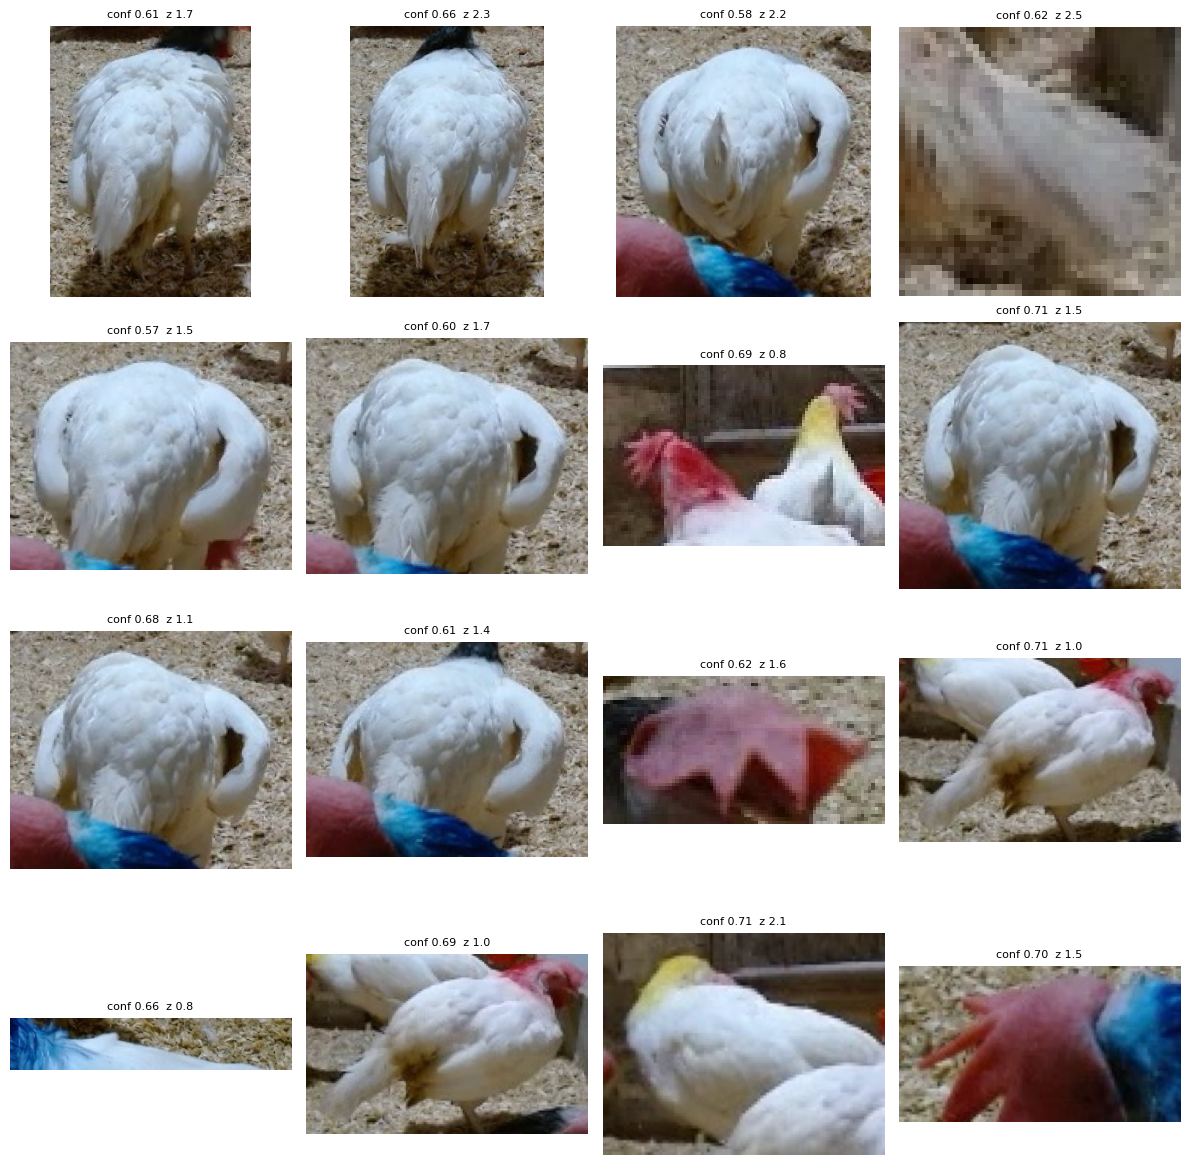

In [6]:
# Review a sample of the selected hard examples.
import matplotlib.pyplot as plt
sel = sorted(selected)[:16]
cols = 4
rows_n = (len(sel) + cols - 1) // cols
fig, ax = plt.subplots(rows_n, cols, figsize=(3 * cols, 3 * rows_n))
ax = np.atleast_1d(ax).ravel()
for k, f in enumerate(sel):
    img = cv2.imread(str(POOL / f))
    row = df[df["file"] == f].iloc[0]
    ax[k].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)); ax[k].axis("off")
    ax[k].set_title(f"conf {row['mean_conf']:.2f}  z {row['max_z']:.1f}", fontsize=8)
for j in range(len(sel), len(ax)):
    ax[j].axis("off")
plt.tight_layout(); plt.show()

## Next steps
- Adjust `BOTTOM_PCT` / `GEOM_Z` / `TARGET` and re-run until the selected montage shows genuinely hard cases (occluded, blurred, odd-angle, overlapping) rather than easy duplicates.
- Label `dataset/pose/pose-crops-to-label/` in Roboflow with the 10-keypoint schema.
- Roboflow exports keypoints in a different order — remap with `PC_FROM_BASE` (see `scripts/merge_pose_crops.py`) when merging.
- Merge the labeled crops + the pre-labeled `pose-crops-fromframes` + existing `pose-crops` into a v3 base, re-augment, and train pose **v5**; compare v4 vs v5 in `eval_pose_crops.ipynb`.